# Sparse Maximum Harmonics-to-Noise-Ratio Deconvolution (SMHD)

When the impacts are **weak**, maximising kurtosis or ICS2 can still
lock onto a louder interferer. SMHD (Miao, Zhao, Lin & Lei,
Measurement Science and Technology 2016) instead maximises the
**harmonics-to-noise ratio** of the envelope autocorrelation at lag
$T$, after a Gaussian-like sparsity map has suppressed the dense
floor:

$$y\leftarrow y\cdot\bigl(1-e^{-y^2/(2\mu^2)}\bigr).$$

The inverse FIR is

$$f=\bigl(2A\bigr)^{-1} r_{yx}(T),$$

where $A$ is the Toeplitz autocovariance of the *raw* $x$
(built once) and $r_{yx}$ is a lag-$T$ weighted cross-correlation
of the sparsified output. $T$ is the same envelope-ACF estimator
as IMCKD (MATLAB ``TT``), and $\mu$ is adapted from the change in
kurtosis:

$$\Delta_k=\frac{\mathrm{kurt}(f_{\mathrm{new}}*x)}{\mathrm{kurt}(y_{\mathrm{old}})},
\qquad
\mu\leftarrow\mu\cdot
\begin{cases}
1+0.02(\Delta_k+1)/\Delta_k & \Delta_k>1,\\
1-0.02(\Delta_k+1)/\Delta_k & \text{otherwise.}
\end{cases}$$

The returned $y$ is the **sparsified** trace at the iteration of
maximum HNR, matching ``smhd.m`` (not the raw FIR output).

$$\mathrm{HNR}=\frac{r_{\max}}{1-r_{\max}}$$

is read from the ACF peak after the first zero-crossing.

**References**

> Y. Miao, M. Zhao, J. Lin, Y. Lei, *Sparse maximum
> harmonics-to-noise-ratio deconvolution for weak fault signature
> detection in bearings*, Measurement Science and Technology 27
> (2016) 105004.

> Y. Miao, B. Zhang, J. Lin et al., *A review on the application of
> blind deconvolution in machinery fault diagnosis*, Mechanical
> Systems and Signal Processing 163 (2022) 108202.


## 1. Imports


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

print("pysdkit from:", Path(__import__("pysdkit").__file__).resolve())

from pysdkit.data import load_smhd_sig3
from pysdkit.utils import (
    annotate_harmonics,
    envelope_spectrum,
    matlab_kurtosis,
    peak_frequency,
    smhd,
)

pysdkit from: C:\Users\whenx\Desktop\PySDKit\pysdkit\__init__.py


## 2. What the code computes

1. If $T$ is omitted, estimate it from the raw envelope ACF
   (``TT``) and round it. Initialise $f$ as a centred
   differentiator $[+1,-1]$.
2. Filter $y=f*x$; log kurtosis and envelope HNR *before*
   sparsity.
3. Apply the sparse map with the current $\mu$ (the MATLAB demo
   uses $1.5\,\mathrm{rms}(x)$, not the code default
   $\mathrm{mean}(x)$).
4. Build the lag-$T$ weighted cross-correlation against $x$;
   $f\leftarrow (2A)^{-1} r$; unit-normalise $f$.
5. Adapt $\mu$ from the kurtosis ratio; re-estimate $T$ from
   the envelope of the **sparsified** $y$ (the loop does not
   re-round $T$; $A$ is never rebuilt).
6. Keep the sparsified $y$ of maximum HNR.

Like IMCKD, SMHD always runs ``term_iter`` iterations. It still
assumes one dominant envelope period. Several incommensurate cycles
of similar strength, or a cycle that lives in the carrier rather
than the envelope, will mislead ``TT``.


## 3. MATLAB demo (``03 SMHD/demo.m``)

Packaged ``sig3.mat``: 20001 samples at $f_s=20\,\mathrm{kHz}$.
Call ``smhd(fs, x, 100, 30, 1.5*rms(x), [], 0)``. The demo marks
**BPFI = 38 Hz**.


N = 20001 fs = 20000.0 BPFI = 38.0 rms = 0.4243081703236992


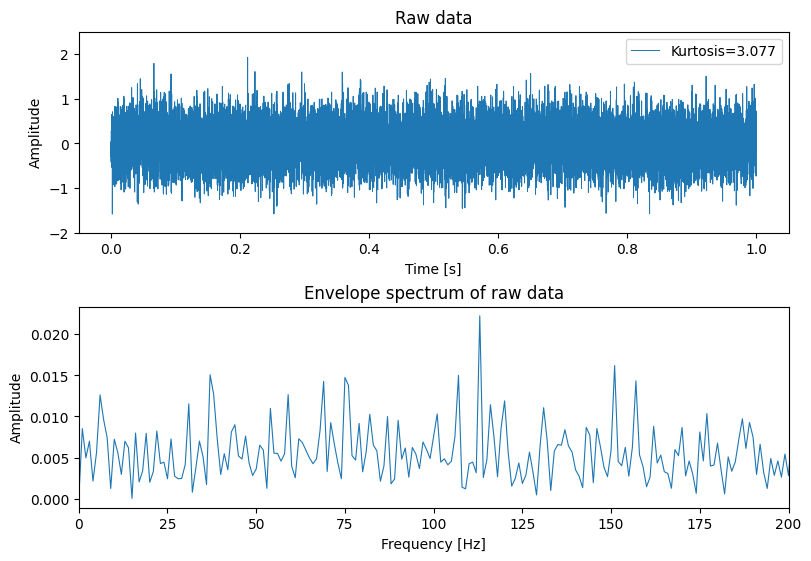

In [2]:
record = load_smhd_sig3()
x = record["signal"] - np.mean(record["signal"])
fs = float(record["fs"])
t = record["t"]
bpfi = float(record["bpfi"])
rms = float(np.sqrt(np.mean(x**2)))
print("N =", x.size, "fs =", fs, "BPFI =", bpfi, "rms =", rms)

freq_x, spec_x = envelope_spectrum(x, fs, scale="fs")
fig, axes = plt.subplots(2, 1, figsize=(8, 5.5), constrained_layout=True)
axes[0].plot(t, x, color="C0", lw=0.7)
axes[0].set_ylim(-2, 2.5)
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Raw data")
axes[0].legend([f"Kurtosis={matlab_kurtosis(x):.3f}"], loc="upper right")
axes[1].plot(freq_x, spec_x, color="C0", lw=0.8)
axes[1].set_xlim(0, 200)
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Envelope spectrum of raw data")
plt.show()

## 4. Run SMHD


||f|| = 1.0
HNR max = 1.3503393606954022 final T = 3187
kurtosis(y) = 19.88513498684657
envelope peak in [0, 200] Hz: 37.99810009499525


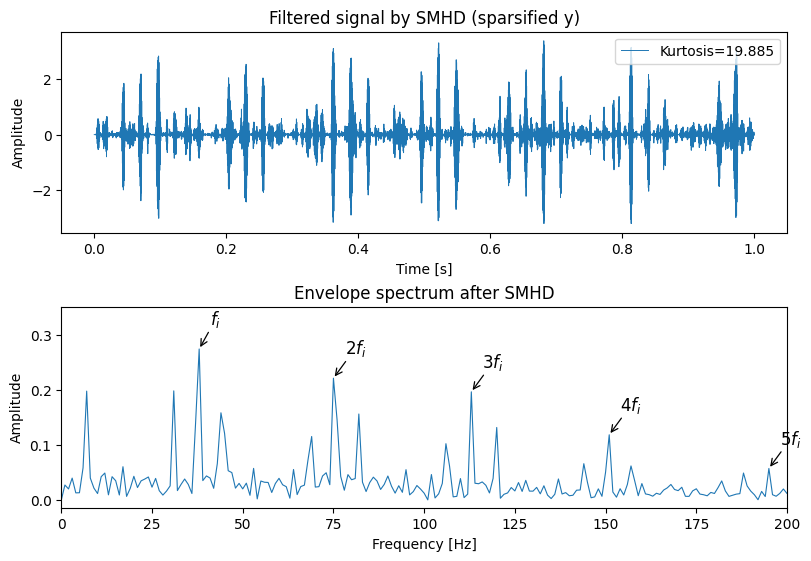

In [3]:
y, fir, info = smhd(x, fs, filter_size=100, term_iter=30, mu=1.5 * rms)
print("||f|| =", np.linalg.norm(fir))
print("HNR max =", info["hnr_max"], "final T =", info["period"])
print("kurtosis(y) =", matlab_kurtosis(y))

freq_y, spec_y = envelope_spectrum(y, fs, scale="fs")
peak = peak_frequency(freq_y, spec_y, f_max=200.0)
print("envelope peak in [0, 200] Hz:", peak)

fig, axes = plt.subplots(2, 1, figsize=(8, 5.5), constrained_layout=True)
axes[0].plot(t, y, color="C0", lw=0.7)
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Filtered signal by SMHD (sparsified y)")
axes[0].legend([f"Kurtosis={matlab_kurtosis(y):.3f}"], loc="upper right")
axes[1].plot(freq_y, spec_y, color="C0", lw=0.8)
axes[1].set_xlim(0, 200)
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Envelope spectrum after SMHD")
annotate_harmonics(freq_y, spec_y, bpfi, n_harmonics=6, ax=axes[1], symbol=r"f_i")
plt.show()